In [ ]:
#Date 05/13/2024

### imported packages
import matplotlib.pyplot as plt
import numpy as np
from netCDF4 import Dataset
from scipy.ndimage import gaussian_filter1d as gf1d
#import from my scripts
import pp_model.PPmodel as pr
import PlotClouds as plot_clouds
import LESProcessing as lesP

# Set image parameters for the notebook
plt.rcParams['figure.figsize'] = [10.0, 6.0]
plt.rcParams['figure.dpi'] = 80
plt.rcParams['savefig.dpi'] = 400

plt.rcParams['font.size'] = 18
plt.rcParams['legend.fontsize'] = 'large'
plt.rcParams['figure.titlesize'] = 'large'

#Save files/ images or not
Save_Files = True

In [ ]:
#set file number
fold_num = 4
file_num = 24
file_num_str = str(file_num).zfill(2)

filename1 = (('LES/%d/Precip/EMUSCU_snd_0' +
                 file_num_str + 
              '/OUT_2D/EMULATOR_SCU_240x240x250_dx200_dz10_dt1s_12h_240_mod.2Dbin_1.nc')%fold_num)

#check if the file exsists or not
try:
    Dataset(filename1)
except FileNotFoundError:
    print('File number incorrect') #continue

    
#load file and info
nc_H = Dataset(filename1)
print(file_num)
ZCT = nc_H.variables['ZCT'][:]
ZCB = nc_H.variables['ZCB'][:]
PREC = nc_H.variables['PREC'][:]
QCLOPD = nc_H.variables['QCLOPD'][:]
CWP = nc_H.variables['CWP'][:]

# Define cloud height
H = ZCT - ZCB # km

24


In [ ]:
#Creates tile width 8 file that we need in order to process the file through the MCMC
try: 
    test = Dataset((('LES/%d/Precip/EMUSCU_snd_0' +
                                         file_num_str + '/EMUSCU_snd_0' 
                                      + file_num_str + '_tw8.nc')%fold_num))
    print('pass')
except: 
    print('not pass, making files')
    #make tile width 8 file
    lesP.save_tile_width_nc_file(X         = H,
                            file_name = (('LES/%d/Precip/EMUSCU_snd_0' +
                                         file_num_str + '/EMUSCU_snd_0' 
                                      + file_num_str + '_tw8.nc')%fold_num),
                            LES_nc    =nc_H,
                            threshold_parameter = CWP,
                            threshold_value     =0,
                            Powers = [3])#[0,1,2,3,4,5,6,7,8,9])
    #make cloud depth movie (i.e. tile width 1)
    my_dataset = Dataset((('LES/%d/Precip/EMUSCU_snd_0' +
                                         file_num_str + '/EMUSCU_snd_0' 
                                      + file_num_str + '_tw1.nc')%fold_num), 'w', format = 'NETCDF4_CLASSIC')
    x = my_dataset.createDimension('x', H.shape[1])
    y = my_dataset.createDimension('y', H.shape[2])
    time = my_dataset.createDimension('time', H.shape[0])
    my_dataset.createVariable('time', np.float64, ('time',))
    my_dataset['time'][:] = nc_H['time'][:]
    var = my_dataset.createVariable('Tile Width 1', np.float64, ('time','y', 'x'))
    my_dataset['Tile Width 1'][:] = H
    my_dataset.close()


pass


In [201]:
# Set tile width you want to use
tile_width = 8

# Set today's date
Date = np.datetime_as_string(np.datetime64('today'))
# Set experiment type 
exp_num = '_exp01'
# creates file_ID
file_ID = Date+exp_num+'_TW%s'%(tile_width)
# Import color scheme
Colors = plot_clouds.Colors()

In [ ]:
# Import Tile width data set
nc_H8 = Dataset(('LES/%d/Precip/EMUSCU_snd_0' +
                                         file_num_str + '/EMUSCU_snd_0' 
                + file_num_str + '_tw8.nc') %fold_num)
#make sure units are in meters
fac = 1000
# Import dimensions
nt,nx,ny = nc_H8.variables['Tile Width %s'%(tile_width)].shape
# Define H_all
Index = np.arange(0,nx,tile_width)
# Multiplying by 1000 to change km into meters (og *1 *)
H_all = fac*nc_H8.variables['Tile Width %s'%(tile_width)][:,Index,Index]
# define the number of tiles horizontal tiles
nTiles = nx//tile_width 
print(nTiles)

30


In [ ]:
#Finds point where clouds are being fully generated 
cc = Dataset(('LES/%d/Precip/EMUSCU_snd_0'+ file_num_str +
             '/EMULATOR_SCU_240x240x250_dx200_dz10_dt1s_12h.nc') %fold_num)
CLDLOW = cc.variables['CLDLOW'][:]
spin_up = pr.find_spinup_end(CLDLOW) #finds spin_up

In [ ]:
#Finds threshold where clouds need to grow above and start below in order to be condsidered a cloud
cc_threshold = 50
my_new_H_all = []
for kk in range(nTiles):
    for jj in range(nTiles):
        for ii in range(len(H_all[spin_up:,0,0])):
            if (H_all[spin_up + ii,jj,kk] > cc_threshold): 
                my_new_H_all.append(H_all[spin_up + ii, jj, kk])
                
prec_thres = np.percentile(my_new_H_all, 75)
print(prec_thres)

np.savetxt(('LES/%d/Precip/EMUSCU_snd_0' +
                                         file_num_str + '/EMUSCU_snd_0' +
                file_num_str + 'cloud_h_thresh_to_find_cycles.txt') %fold_num ,
               [prec_thres], delimiter = ',')

486.25000938773155


In [ ]:
lower_thresh = prec_thres# cloud must start below this depth #keep them the same
upper_thresh = prec_thres # cloud must grow above this depth
sigma = 5       # standard deviation of Gaussian filter for temporal smoother 
time_thresh = 37.5 #minimum length of a cycle (75 minutes)

#Find cycles
XYT = []
for kk in range(nTiles):
    for jj in range(nTiles):
        H = gf1d(H_all[spin_up:,kk,jj],sigma)
        minimums = np.where((H[1:-1] < H[0:-2]) * (H[1:-1] < H[2:]))[0] + 1 
        for pp in range(1, len(minimums)): 
            my_next_min = minimums[-pp - 1]
            my_max = np.argmax(H[my_next_min:minimums[-pp]]) + my_next_min
            if(H[minimums[-pp]] < lower_thresh and H[my_next_min] < lower_thresh and 
                H[my_max] > upper_thresh and minimums[-pp] - my_next_min > time_thresh): 
                t_start = spin_up + my_next_min
                t_end = spin_up + minimums[-pp]
                t_mid = spin_up + my_max
                XYT.append([kk,jj,t_start,t_end,t_mid])
            
print('number of cycles found:', len(XYT))
XYT = np.array(XYT)

number of cycles found: 642


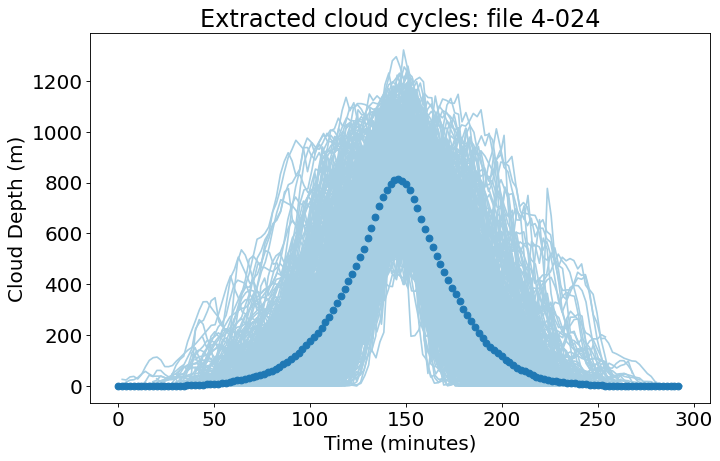

1321.0937827825546 147


In [ ]:
#Plot cycles found and their mean
All_clouds = []
for kk in range(len(XYT)):
    x,y,t1,t2,tmid = XYT[kk,:]
    All_clouds.append(H_all[t1:t2,x,y])
    
longest_cloud = np.max(XYT[:,4]-XYT[:,2])+np.max(XYT[:,3]-XYT[:,4])
mid_cloud = np.max(XYT[:,4]-XYT[:,2])
y_extended = np.zeros((longest_cloud,len(XYT)))
for kk in range(len(XYT)):
    x,y,t1,t2,tmid = XYT[kk,:]

    y_extended[mid_cloud-(tmid-t1):mid_cloud,kk]=H_all[t1:tmid,x,y]
    y_extended[mid_cloud:mid_cloud+(t2-tmid),kk]=H_all[tmid:t2,x,y]
    plt.plot(2*np.linspace((mid_cloud-(tmid-t1)),(mid_cloud+t2-tmid),t2-t1),
             y_extended[mid_cloud-(tmid-t1):mid_cloud+t2-tmid,kk],color=Colors['LES_err'])
    
my_mean = np.mean(y_extended,axis=1)
plt.plot(2*np.arange(longest_cloud ),my_mean,'o',color = Colors['LES'])
plt.title(('Extracted cloud cycles: file %d-0' + file_num_str)%fold_num)
plt.xlabel('Time (minutes)')
plt.ylabel('Cloud Depth (m)')
plt.show()
print(np.max(y_extended),len(y_extended))

if Save_Files:
    np.savetxt(('LES/%d/Precip/EMUSCU_snd_0' +
                                         file_num_str + '/EMUSCU_snd_0' +
                file_num_str + '_tw8_XYT_cycles.txt') %fold_num ,
               y_extended, delimiter = ',')
    np.savetxt(('LES/%d/Precip/EMUSCU_snd_0' +
                                         file_num_str + '/EMUSCU_snd_0' +
                file_num_str + '_tw8_XYT_param.txt') %fold_num ,
               XYT, delimiter = ',')
    np.savetxt(('LES/mean/%d_' + file_num_str + '_infall.txt') %fold_num ,
               my_mean, delimiter = ',')

(147, 642)
New CC condition number: 260.2899030470411
Old Cov condition number: inf


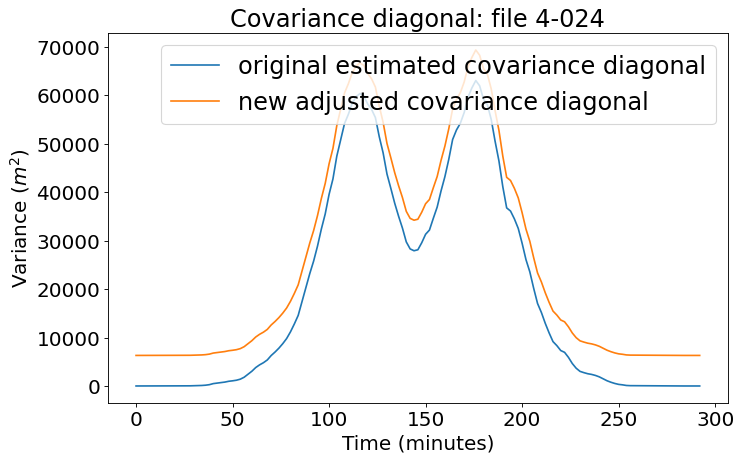

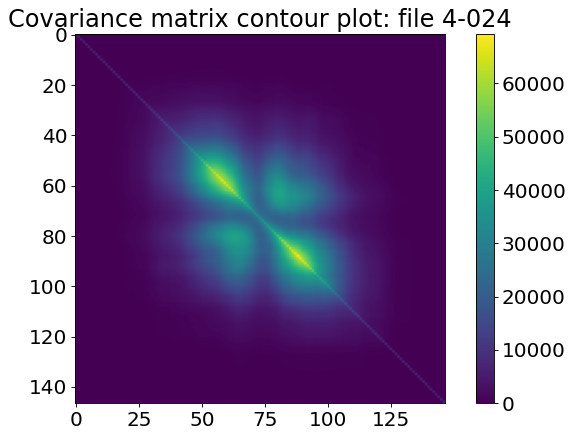

In [ ]:
#Plot covariance diagonal and contour plot of covariance matrix
#Covaraince of LES cycles
Cov = np.cov(y_extended)

# calculate diagonal
Cov_diag = np.diagonal(Cov)

# #Calculate the max variance value
max_Cov_diag = np.amax(Cov_diag)
percentage = 0.1

CCov = Cov + percentage*max_Cov_diag*np.identity(len(Cov))

##Determining Codnition Number 
condition_numberCC = np.linalg.cond(CCov)
condition_number = np.linalg.cond(Cov)
print('New CC condition number:', condition_numberCC)
print('Old Cov condition number:', condition_number)

#Plot covaraince diagonal (variances)
plt.plot(2*np.arange(0, len(my_mean)), np.diag(Cov), label = 'original estimated covariance diagonal')
plt.plot(2*np.arange(0, len(my_mean)), np.diag(CCov), label = 'new adjusted covariance diagonal')
plt.title(('Covariance diagonal: file %d-0' + file_num_str)%fold_num)
plt.xlabel('Time (minutes)')
plt.ylabel('Variance ($m^2$)')
plt.legend()
plt.show()

#Plot covaraince as contour plot
tmp = np.abs(CCov).max()
plt.imshow(CCov,cmap = 'viridis')#,vmin=-tmp,vmax=tmp)
plt.colorbar()
plt.title(('Covariance matrix contour plot: file %d-0' + file_num_str)%fold_num)
plt.show()

if Save_Files:
    np.savetxt(('LES/cov/%d_' +
                                         file_num_str + '_infall.txt') %fold_num, CCov, delimiter = ',')

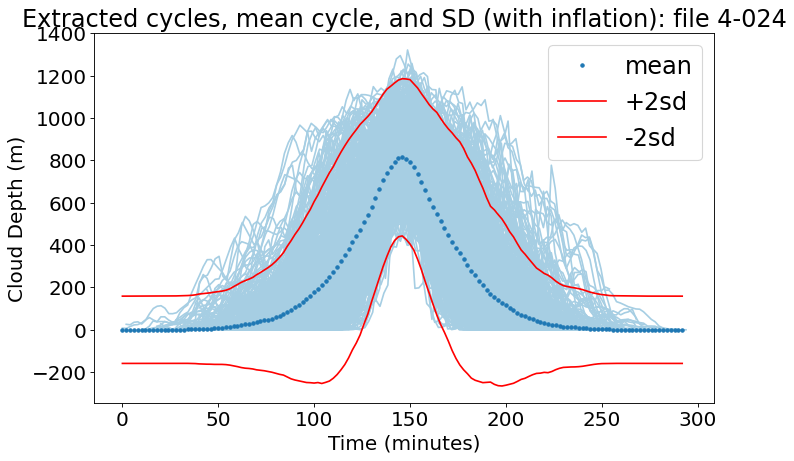

In [208]:
#Plot of cycles, cycle mean, and varaince 
for kk in range(len(XYT)):
    x,y,t1,t2,tmid = XYT[kk,:]
    plt.plot(2*np.linspace((mid_cloud-(tmid-t1)),(mid_cloud+t2-tmid),t2-t1),
             y_extended[mid_cloud-(tmid-t1):mid_cloud+t2-tmid,kk],color=Colors['LES_err'])
    
plt.plot(2*np.arange(longest_cloud ),   #[(my_i[0,0] - 1):(my_i[-1,0])]
         my_mean,
         '.',color = Colors['LES'], label = 'mean')
plt.plot(2*np.arange(longest_cloud ),
         my_mean + 2*np.sqrt(np.diag(CCov)),   #new_Cov
         '-',color = 'red', label = '+2sd')
plt.plot(2*np.arange(longest_cloud ),
         my_mean - 2*np.sqrt(np.diag(CCov)),
         '-',color = 'red', label = '-2sd')
plt.xlabel('Time (minutes)')
plt.ylabel('Cloud Depth (m)')
plt.title(('Extracted cycles, mean cycle, and SD (with inflation): file %d-0' + file_num_str)%fold_num)
plt.legend()
plt.show()

In [ ]:
#FInding droplet concentration value
CLD = cc.variables['CLD'][:]
N_data = cc.variables['NC'][:]
N_ave = np.mean(N_data, axis=1) / np.mean(CLD, axis=1)

#Concentration adjusted to be correct time units
N = np.mean(N_ave[spin_up:])*1E6

old_N = 25E6

#Save droplet concentration value
np.savetxt(('LES/%d/Precip/EMUSCU_snd_0' + file_num_str + '/EMUSCU_snd_0' +
                file_num_str + 'drop_conc_N.txt') %fold_num ,
               [N], delimiter = ',')